In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

pd.set_option("display.max_columns", None)

sns.set_theme(palette="bright")

In [12]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,concavity_se,concavity_worst,diagnosis,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,0.05373,0.7119,M,0.07871,0.006193,0.11890,122.80,8.589,184.60,17.99,1.0950,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,0.01860,0.2416,M,0.05667,0.003532,0.08902,132.90,3.398,158.80,20.57,0.5435,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,0.03832,0.4504,M,0.05999,0.004571,0.08758,130.00,4.585,152.50,19.69,0.7456,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,0.05661,0.6869,M,0.09744,0.009208,0.17300,77.58,3.445,98.87,11.42,0.4956,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,0.05688,0.4000,M,0.05883,0.005115,0.07678,135.10,5.438,152.20,20.29,0.7572,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [13]:
# Separando as variáveis preditoras e a variável alvo
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [14]:
# Transformando a variável alvo em numérica
y = LabelEncoder().fit_transform(y)
y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
# kf
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [16]:
# Criando o pipeline de Preprocessamento para os modelos
preprocessor = Pipeline(
    [
        ("power_transformer", PowerTransformer()),
    ]
)

In [17]:
classificadores = {
    "Dummy Classifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified"),
        
    },
    "Perceptron": {
        "preprocessor": preprocessor,
        "classificador": Perceptron(),
    },
    "LogisticRegression": {
        "preprocessor": preprocessor,
        "classificador": LogisticRegression(),
    },
    "SGDClassifier": {
        "preprocessor": preprocessor,
        "classificador": SGDClassifier(),
    }
}

In [18]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(
        X,
        y,
        kf,
        **classificador
    )
    for nome_modelo, classificador in classificadores.items()
}
resultados_organizados = organiza_resultados(resultados)
resultados_organizados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,Dummy Classifier,0.002,0.027986,0.5,0.48395,0.387097,0.36,0.418605,0.488863,0.372149,0.029986
1,Dummy Classifier,0.002,0.024984,0.491228,0.463151,0.340909,0.333333,0.348837,0.542745,0.400402,0.026985
2,Dummy Classifier,0.001997,0.024987,0.552632,0.501984,0.337662,0.371429,0.309524,0.50496,0.370771,0.026984
3,Dummy Classifier,0.003004,0.028978,0.45614,0.435516,0.326087,0.3,0.357143,0.498016,0.367504,0.031982
4,Dummy Classifier,0.002998,0.025983,0.575221,0.535547,0.4,0.421053,0.380952,0.448357,0.351491,0.028982
5,Perceptron,0.551683,0.026985,0.947368,0.953161,0.933333,0.893617,0.976744,0.992139,0.98945,0.578667
6,Perceptron,0.497761,0.042974,0.964912,0.96266,0.953488,0.953488,0.953488,0.99869,0.997909,0.540736
7,Perceptron,0.524713,0.039964,0.947368,0.943452,0.928571,0.928571,0.928571,0.982474,0.977233,0.564677
8,Perceptron,0.503709,0.023001,0.973684,0.979167,0.965517,0.933333,1.0,1.0,1.0,0.52671
9,Perceptron,0.469389,0.026,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.49539


In [19]:
resultados_organizados.groupby ("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
Dummy Classifier,0.0024,0.026584,0.515044,0.48403,0.358351,0.357163,0.363012,0.496588,0.372463,0.028984
LogisticRegression,0.568677,0.037574,0.975408,0.970873,0.96636,0.981258,0.952935,0.996632,0.995721,0.606251
SGDClassifier,0.494775,0.02719,0.964881,0.963398,0.953328,0.950469,0.957586,0.993726,0.991549,0.521965
Perceptron,0.509451,0.031785,0.966667,0.967688,0.956182,0.941802,0.971761,0.99466,0.992919,0.541236


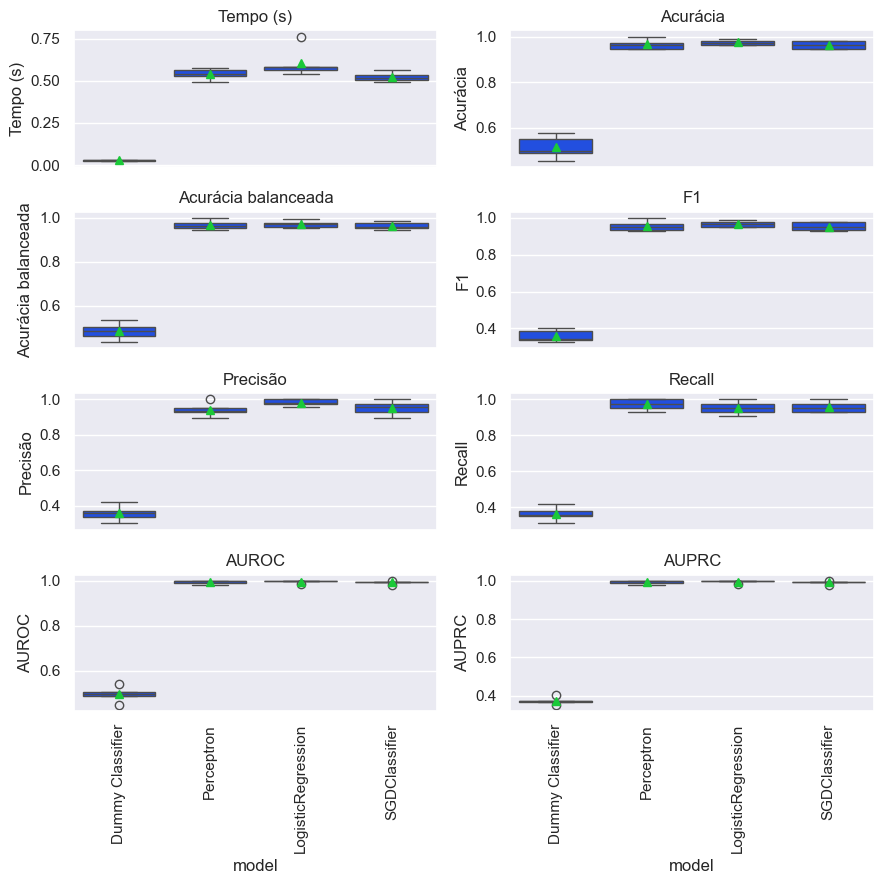

In [20]:
plot_comparar_metricas_modelos(resultados_organizados)

In [21]:
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__l1_ratio": [0.0, 0.1, 0.5, 1.0],
    "clf__class_weight": [None, "balanced"],
}

In [22]:
clf = LogisticRegression(solver='saga', random_state=RANDOM_STATE)
grid_search = grid_search_cv_classificador(
    clf,
    param_grid,
    kf,
    preprocessor=preprocessor,
    refit_metric="recall"
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [23]:
grid_search.fit(X,y)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [24]:
grid_search.best_params_

{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.0}

In [25]:
grid_search.best_score_

np.float64(0.9623477297895903)

In [26]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('power_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization

In [27]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_se', 'compactness_worst', 'concave points_mean',
       'concave points_se', 'concave points_worst', 'concavity_mean',
       'concavity_se', 'concavity_worst', 'fractal_dimension_mean',
       'fractal_dimension_se', 'fractal_dimension_worst',
       'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_mean',
       'radius_se', 'radius_worst', 'smoothness_mean', 'smoothness_se',
       'smoothness_worst', 'symmetry_mean', 'symmetry_se',
       'symmetry_worst', 'texture_mean', 'texture_se', 'texture_worst'],
      dtype=object)

In [28]:
grid_search.best_estimator_["clf"].coef_

array([[ 0.30776287,  0.51249108,  0.45442998, -0.08335921, -0.33172553,
         0.07880288,  0.49038811,  0.13461129,  0.45020865,  0.42494766,
         0.05462929,  0.44867428, -0.18393306, -0.25154422,  0.12127362,
         0.28292902,  0.30080053,  0.39246367,  0.28248957,  0.43920334,
         0.42714151,  0.21077149, -0.04788555,  0.44371669,  0.1529948 ,
        -0.34752493,  0.38844761,  0.51214069, -0.04745209,  0.60874479]])

In [29]:
df_coef = dataframe_coeficientes( 
    grid_search.best_estimator_["clf"].coef_[0],
    grid_search.best_estimator_["preprocessor"].get_feature_names_out(),
)
df_coef

,coeficiente
symmetry_se,-0.347525
compactness_se,-0.331726
fractal_dimension_se,-0.251544
fractal_dimension_mean,-0.183933
compactness_mean,-0.083359
smoothness_se,-0.047886
texture_se,-0.047452
concavity_se,0.054629
compactness_worst,0.078803
fractal_dimension_worst,0.121274


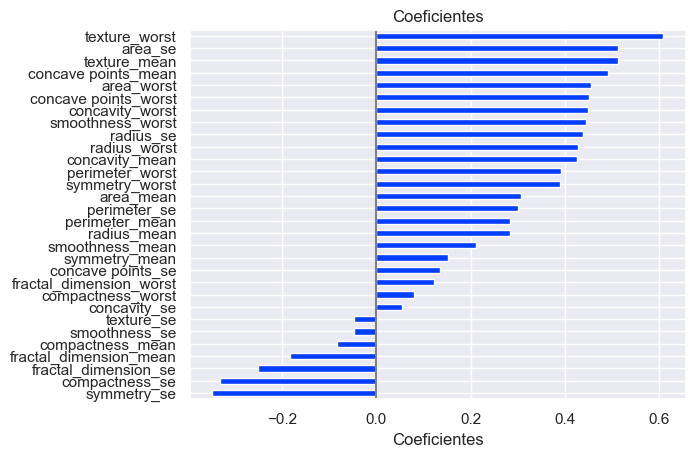

In [30]:
plot_coeficientes(df_coef)

In [31]:
#Odds Ratio
coef_odds = df_coef.copy()
coef_odds["coeficiente"] = np.exp(coef_odds["coeficiente"])

coef_odds.sort_values("coeficiente", ascending=False)

,coeficiente
texture_worst,1.838123
area_se,1.669445
texture_mean,1.668860
concave points_mean,1.632950
area_worst,1.575275
concave points_worst,1.568639
concavity_worst,1.566234
smoothness_worst,1.558489
radius_se,1.551471
radius_worst,1.532870


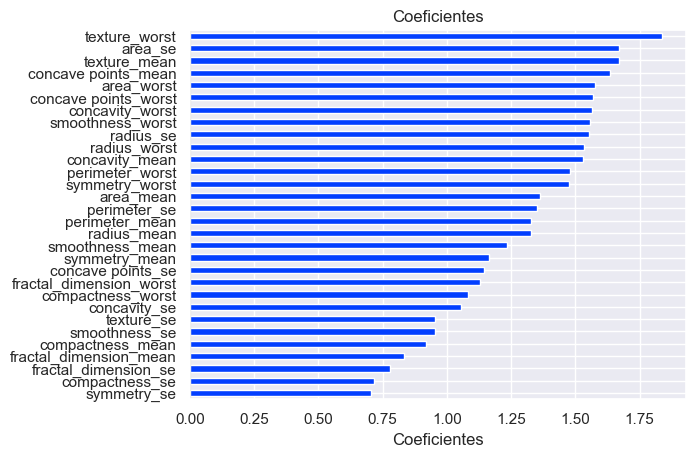

In [32]:
plot_coeficientes(coef_odds)

In [33]:
X_scaled = grid_search.best_estimator_["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out())
X_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,concavity_se,concavity_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1.126421,1.876109,1.652210,2.165938,1.445854,1.942737,1.848558,0.810200,1.935654,1.862988,1.155514,1.730182,1.886398,1.345552,1.723624,1.259822,1.973081,1.810506,1.134881,1.892785,1.619635,1.504114,-0.030553,1.282792,1.953067,1.355589,2.197206,-2.678666,-0.498201,-1.488367
1,1.633946,1.276861,1.610022,-0.384102,-0.793830,-0.296580,0.820609,0.426936,1.101594,0.291976,-0.463804,0.070746,-0.956577,0.188240,0.537179,1.528723,0.732407,1.430616,1.619346,0.958616,1.578689,-0.820227,-0.633991,-0.325080,0.102291,-1.028611,-0.121997,-0.264377,-0.998312,-0.288382
2,1.461645,1.496107,1.425307,1.163977,1.121521,1.209701,1.683104,1.423361,1.722744,1.403673,0.595624,1.005512,-0.292433,0.744186,0.453955,1.454664,1.213029,1.321941,1.464796,1.457817,1.419757,0.963977,-0.148581,0.580301,0.985668,0.568436,1.218181,0.547806,-0.833982,0.071406
3,-0.836238,0.045515,-0.436860,2.197843,1.964874,2.282276,1.423004,1.191720,1.862378,1.642391,1.240838,1.675087,2.708925,1.943212,2.517606,-0.514886,0.756164,-0.039480,-0.759262,0.791676,-0.083692,2.781494,0.975445,2.857821,2.360528,2.350939,3.250202,0.357721,0.097022,0.228089
4,1.595120,1.499885,1.309486,0.762392,0.253010,-0.131829,1.410929,1.214491,0.807077,1.407479,1.248567,0.817474,-0.511332,0.976884,-0.279402,1.583341,1.451685,1.316582,1.571260,1.479006,1.293727,0.343932,1.545561,0.284367,0.090964,-0.227814,-0.943554,-1.233520,-0.850908,-1.637882


In [34]:
df_scaled = pd.concat([X_scaled, pd.Series(y, name="diagnosis")], axis=1)
df_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,concavity_se,concavity_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst,diagnosis
0,1.126421,1.876109,1.652210,2.165938,1.445854,1.942737,1.848558,0.810200,1.935654,1.862988,1.155514,1.730182,1.886398,1.345552,1.723624,1.259822,1.973081,1.810506,1.134881,1.892785,1.619635,1.504114,-0.030553,1.282792,1.953067,1.355589,2.197206,-2.678666,-0.498201,-1.488367,1
1,1.633946,1.276861,1.610022,-0.384102,-0.793830,-0.296580,0.820609,0.426936,1.101594,0.291976,-0.463804,0.070746,-0.956577,0.188240,0.537179,1.528723,0.732407,1.430616,1.619346,0.958616,1.578689,-0.820227,-0.633991,-0.325080,0.102291,-1.028611,-0.121997,-0.264377,-0.998312,-0.288382,1
2,1.461645,1.496107,1.425307,1.163977,1.121521,1.209701,1.683104,1.423361,1.722744,1.403673,0.595624,1.005512,-0.292433,0.744186,0.453955,1.454664,1.213029,1.321941,1.464796,1.457817,1.419757,0.963977,-0.148581,0.580301,0.985668,0.568436,1.218181,0.547806,-0.833982,0.071406,1
3,-0.836238,0.045515,-0.436860,2.197843,1.964874,2.282276,1.423004,1.191720,1.862378,1.642391,1.240838,1.675087,2.708925,1.943212,2.517606,-0.514886,0.756164,-0.039480,-0.759262,0.791676,-0.083692,2.781494,0.975445,2.857821,2.360528,2.350939,3.250202,0.357721,0.097022,0.228089,1
4,1.595120,1.499885,1.309486,0.762392,0.253010,-0.131829,1.410929,1.214491,0.807077,1.407479,1.248567,0.817474,-0.511332,0.976884,-0.279402,1.583341,1.451685,1.316582,1.571260,1.479006,1.293727,0.343932,1.545561,0.284367,0.090964,-0.227814,-0.943554,-1.233520,-0.850908,-1.637882,1


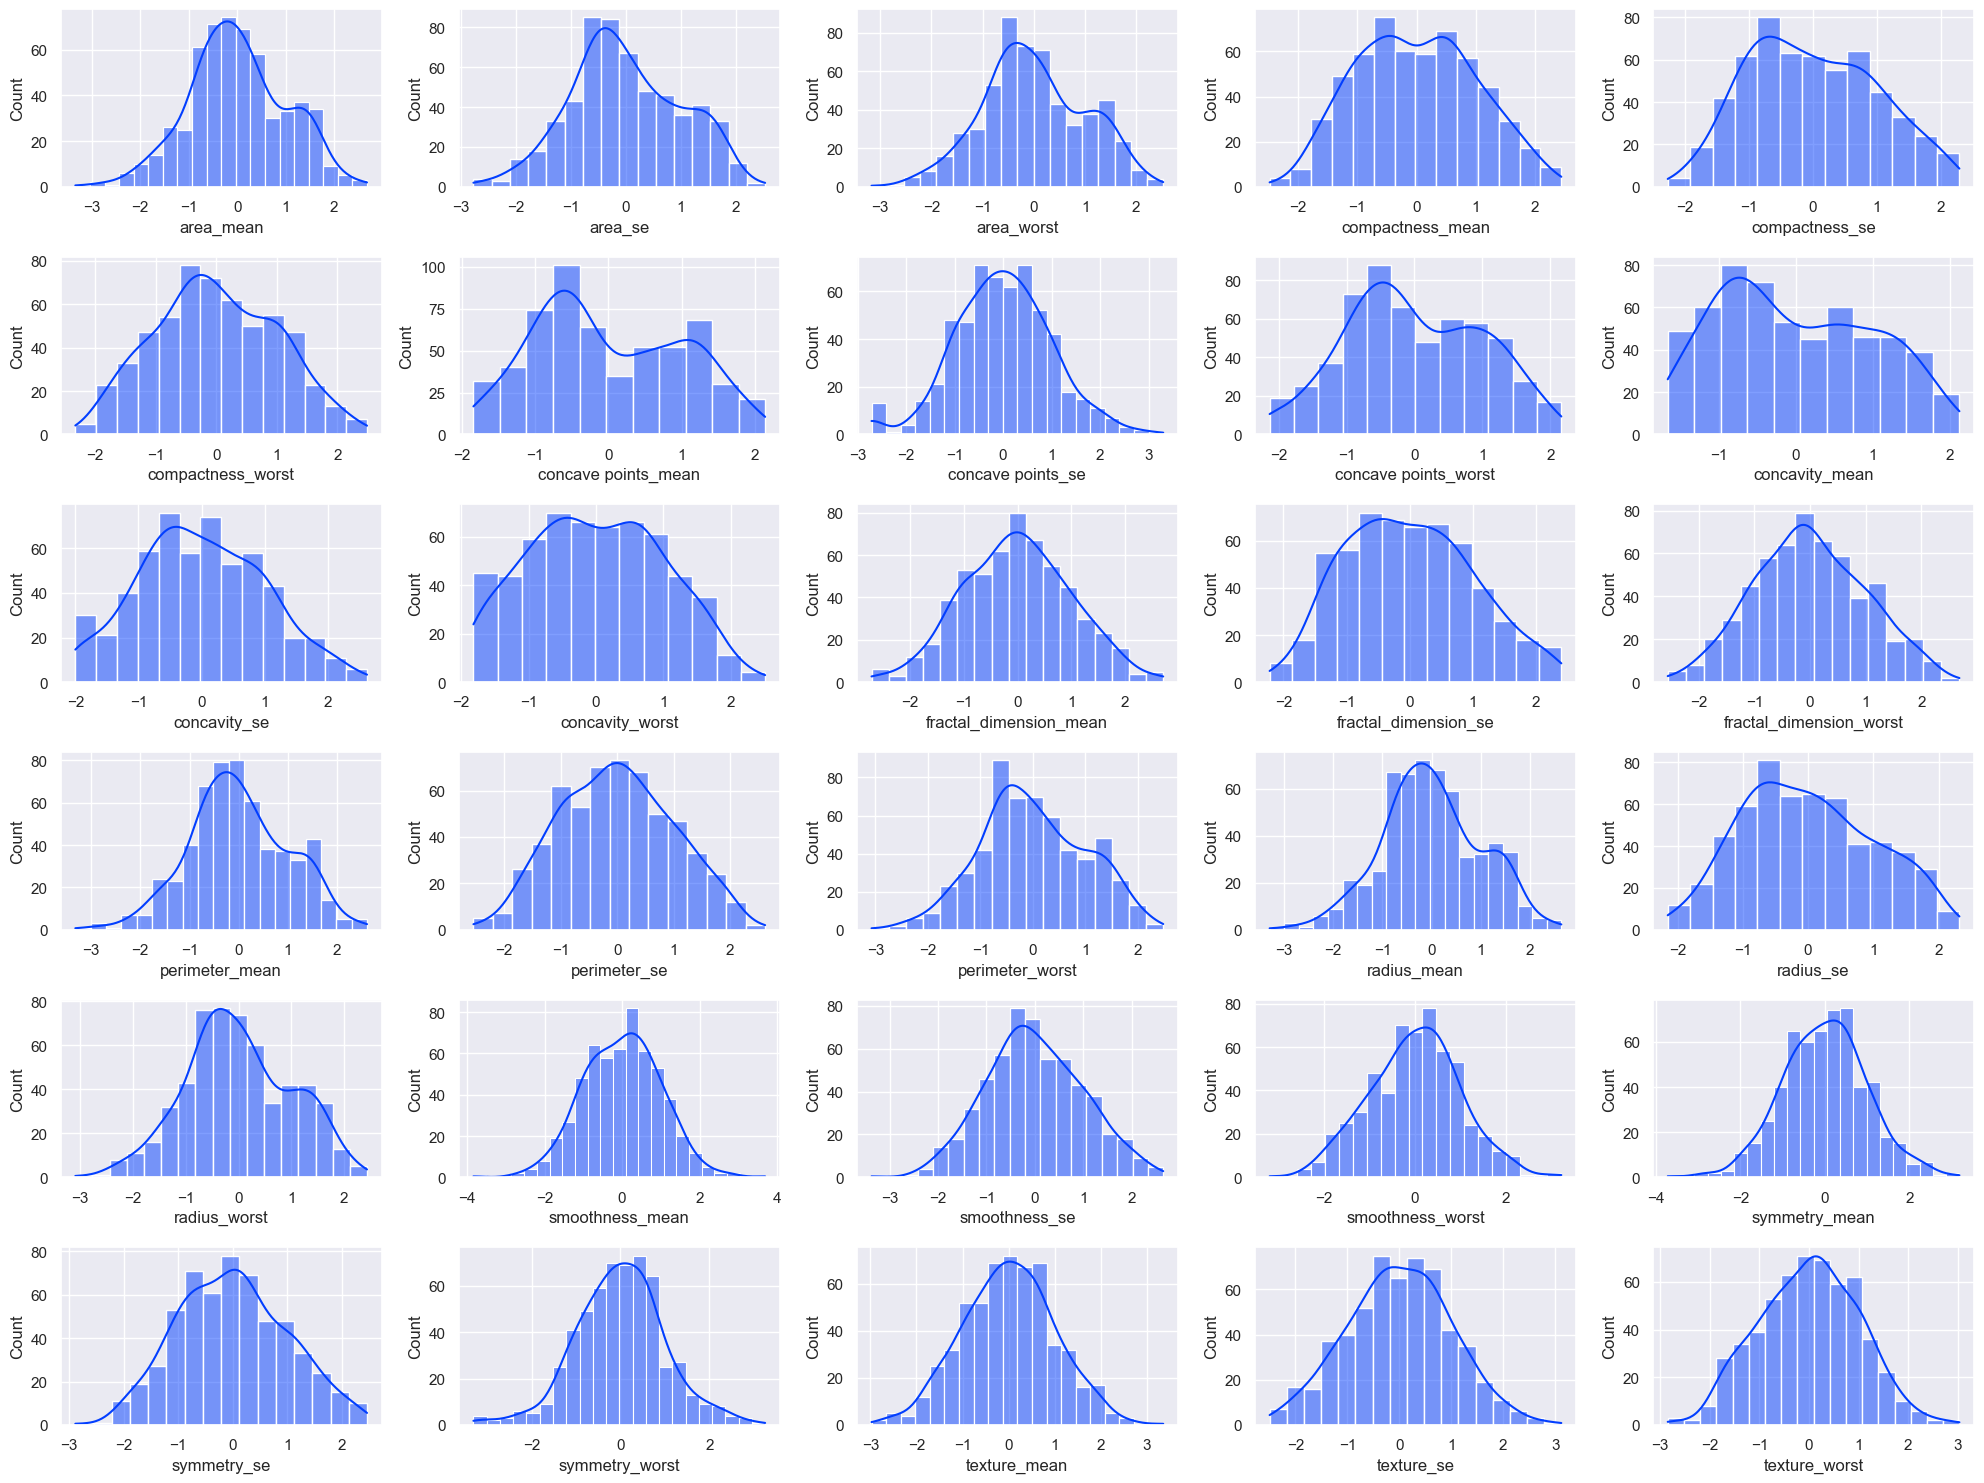

In [35]:
#Análise das distribuições das variáveis numéricas
fig, axs = plt.subplots(6, 5, figsize=(20, 15))
for i, column in enumerate(df.select_dtypes(include=np.number).columns):
    sns.histplot(data=df_scaled, x=column, ax=axs[i//5, i%5], kde=True)
plt.tight_layout()
plt.show()

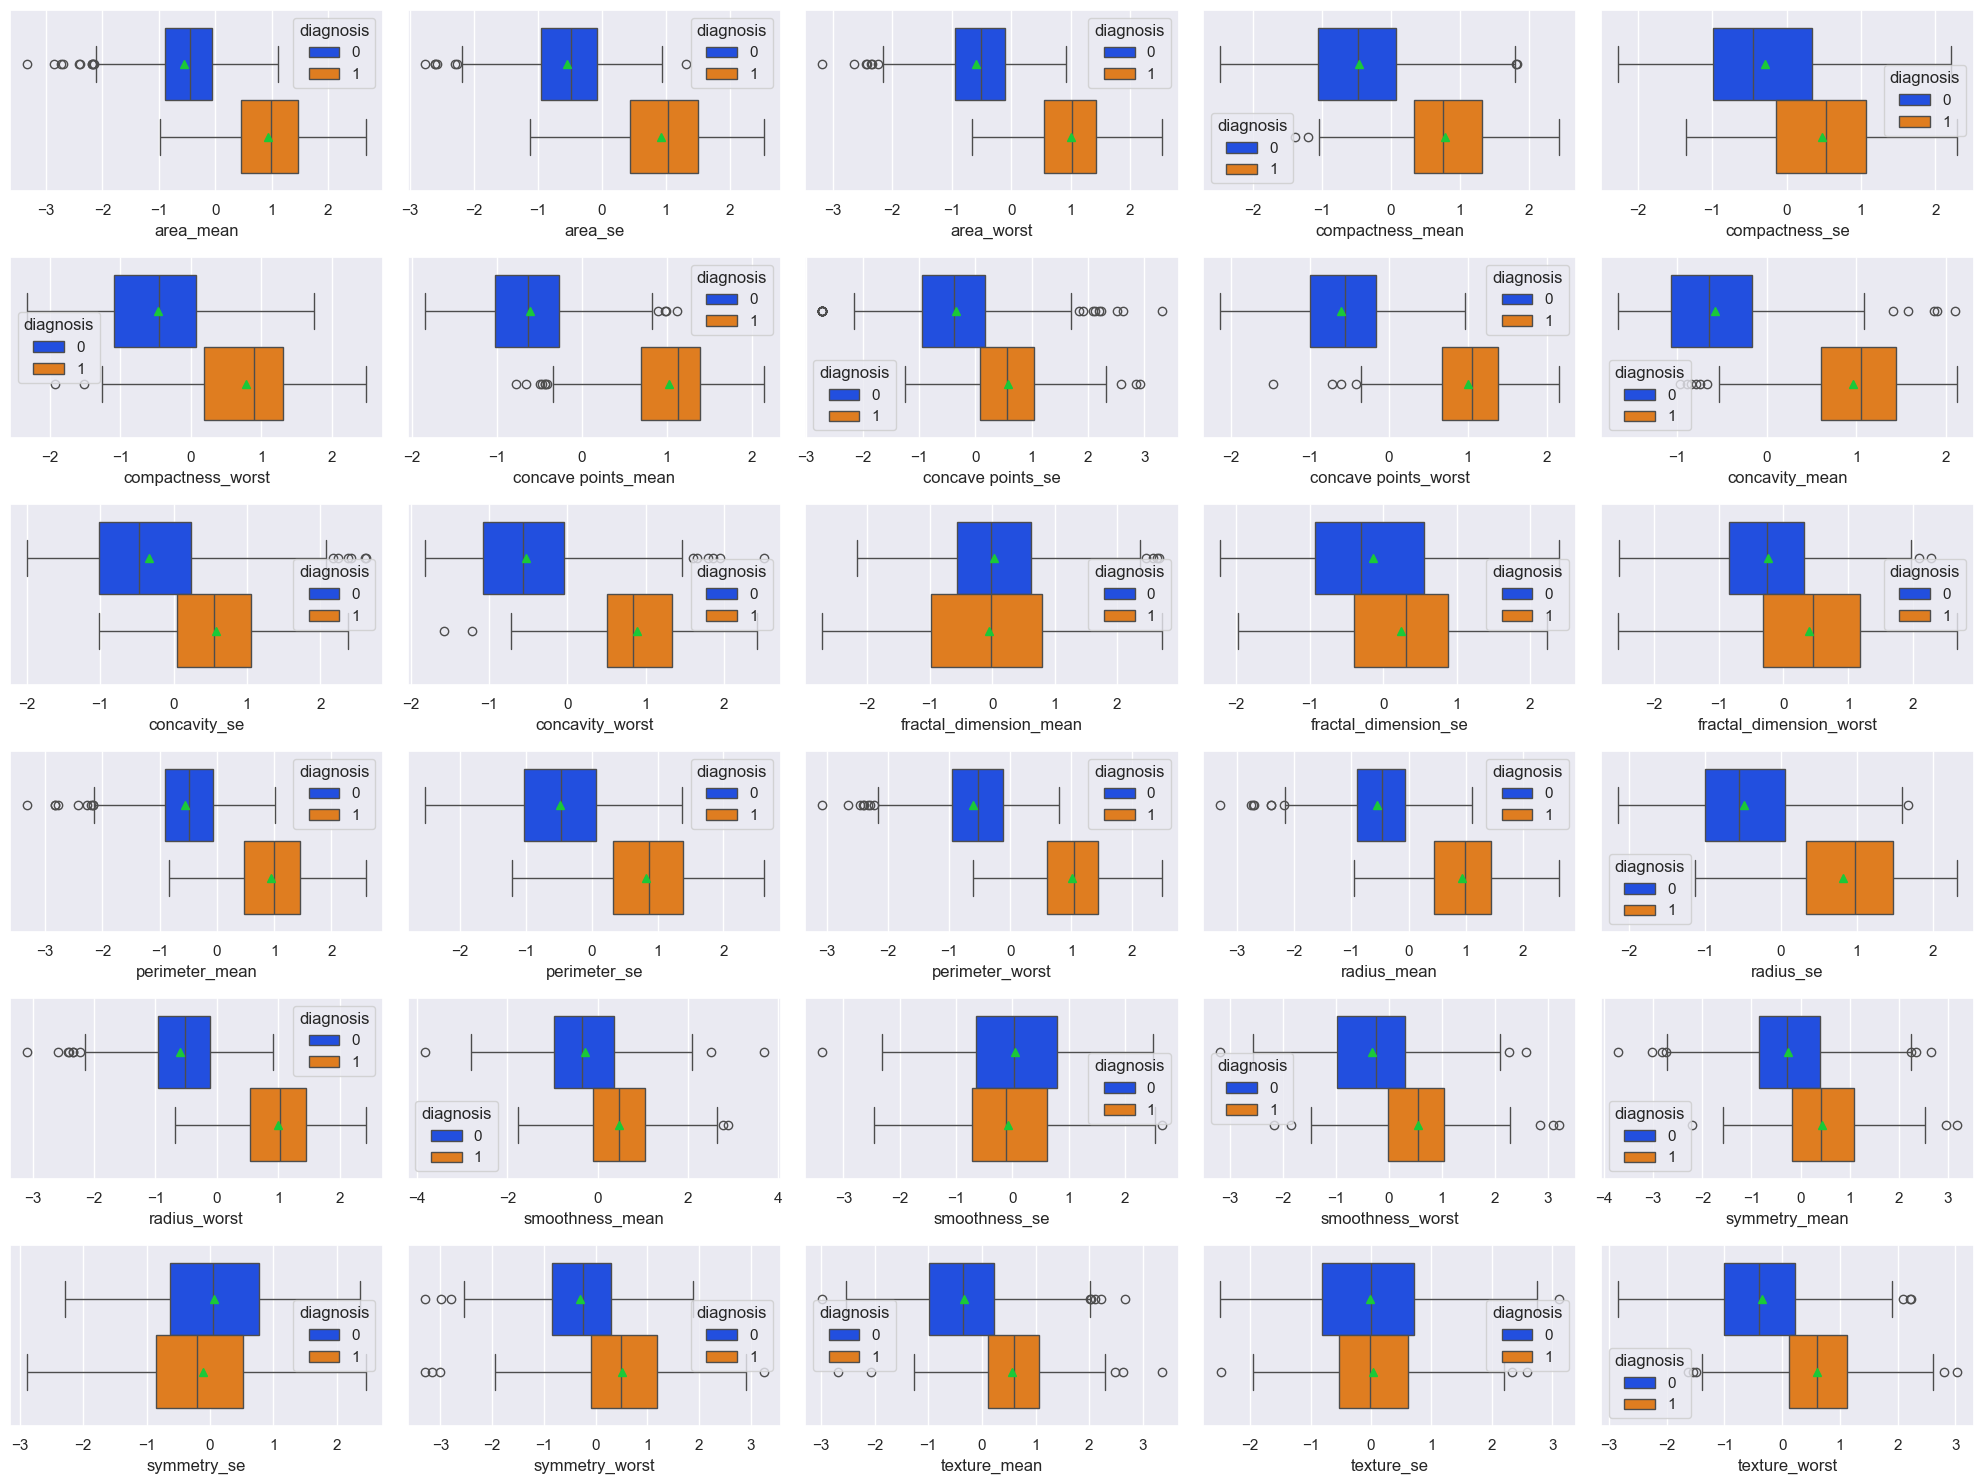

In [36]:
#Análise das distribuições das variáveis numéricas
fig, axs = plt.subplots(6, 5, figsize=(20, 15))
for i, column in enumerate(df.select_dtypes(include=np.number).columns):
    sns.boxplot(data=df_scaled, x=column, showmeans=True, ax=axs[i//5, i%5], hue = 'diagnosis')
plt.tight_layout()
plt.show()